In [14]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import torch
import cv2
import json
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

from pathlib import Path
import sys
from typing import Any
import PIL.Image

from project_root import PROJECT_ROOT,DATASETS_ROOT

import fiftyone as fo
import fiftyone.utils.torch as fout

from tqdm.auto import tqdm
import torchvision as tv

from scripts.model_serialization import load_model

np.set_printoptions(linewidth=200)
no_grad_guard = torch.no_grad()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# dataset_name =         "zoo-elephants-identity-tracks"
# ds =fo.load_dataset(dataset_name)


def make_ds():
    return fo.Dataset.from_dir(
        dataset_type=fo.types.ImageDirectory,
        dataset_dir="/media/dherrera/ElephantExternal/elephants/tracks/new/identity/03_Fahra/zag_elp_cam_018_000342",
        persistent=False,
    )


ds = make_ds()
# classes = sorted(ds.classes["ground_truth"])
# print(classes)
print(ds)

 100% |█████████████████| 656/656 [45.0ms elapsed, 0s remaining, 14.6K samples/s]  
Name:        2025.04.08.10.40.47
Media type:  image
Num samples: 656
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField


In [16]:
# Compute uniqueness
import fiftyone.brain as fob

session = fo.launch_app(ds, auto=False)
session.open_tab()

Session launched. Run `session.show()` to open the App in a cell output.


<IPython.core.display.Javascript object>

In [17]:
import transformers

embeddings_model_path = PROJECT_ROOT / "models/identity/vit/all/config.json"
image_processor = transformers.AutoImageProcessor.from_pretrained(
    embeddings_model_path.parent
)
embeddings_model = load_model(embeddings_model_path)
embeddings_model = embeddings_model.vit.embeddings
embeddings_model

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)

In [18]:
MAX_KEYFRAMES = 20
keyframe_images = []
keyframe_embeddings = []
keyframe_similarities = torch.ones((0, 0))

sample_iter = ds.iter_samples()

In [ ]:
def replace_similarity_matrix_entry(m, idx, v):
    vidx = min(len(v), idx)
    m[0:idx, idx] = v[0:vidx]
    m[idx, 0:idx] = v[0:vidx]
    if idx < len(m) - 1:
        m[idx + 1 :, idx] = v[vidx + 1 :]
        m[idx, idx + 1 :] = v[vidx + 1 :]


for si, sample_i in tqdm(enumerate(ds.iter_samples())):
    try:
        image_path = sample_i["filepath"]
        image = PIL.Image.open(image_path)
        image = np.asarray(image)
        pixel_values = image_processor.preprocess(image)["pixel_values"]
        pixel_values = np.stack(pixel_values, 0)
        pixel_values = torch.from_numpy(pixel_values)
        embeddings_i = embeddings_model.forward(pixel_values)
        embeddings_i_norm = torch.linalg.norm(embeddings_i.reshape(-1))

        # Get the similarity between new image and keyframes
        similarities_i = torch.tensor(
            [
                torch.dot(embeddings_i.reshape(-1), kf.reshape(-1))
                / (torch.linalg.norm(kf) * embeddings_i_norm)
                for kf in keyframe_embeddings
            ]
        )
        max_similarity_i, max_similarity_i_idx = (
            torch.max(similarities_i, dim=0) if len(similarities_i) > 0 else (0, 0)
        )
        MAX_SIMILARITY_THRESHOLD = 0.8
        if max_similarity_i > MAX_SIMILARITY_THRESHOLD:
            msg = f"Skipping frame due to high similarity: {max_similarity_i}"
        else:
            keyframe_count = len(keyframe_images)
            if keyframe_count < MAX_KEYFRAMES:
                msg = "Adding new keyframe"
                keyframe_images.append(image)
                keyframe_embeddings.append(embeddings_i)
                new_similarities = torch.empty((keyframe_count + 1, keyframe_count + 1))
                new_similarities[0:keyframe_count, 0:keyframe_count] = (
                    keyframe_similarities
                )
                new_similarities[0:keyframe_count, keyframe_count] = similarities_i
                new_similarities[keyframe_count, 0:keyframe_count] = similarities_i
                new_similarities[keyframe_count, keyframe_count] = 0
                keyframe_similarities = new_similarities
            else:
                # Get the highest similarity between keyframes
                keyframe_highest_similarities, keyframe_highest_similarities_idx = (
                    torch.max(keyframe_similarities, dim=0)
                )  # [keyframe], [keyframe]
                highest_similarity, highest_similarity_idx = torch.max(
                    keyframe_highest_similarities, dim=0
                )  # scalar, scalar
                most_similar_frame_idxs = [
                    highest_similarity_idx.item(),
                    keyframe_highest_similarities_idx[highest_similarity_idx].item(),
                ]

                if max_similarity_i < highest_similarity:
                    # Replace a keyframe
                    most_similar_frame_l2 = torch.linalg.norm(
                        keyframe_similarities[most_similar_frame_idxs]
                    )
                    _, idx = torch.max(most_similar_frame_l2, dim=0)
                    keyframe_to_replace_idx = most_similar_frame_idxs[idx]
                    msg = f"Replacing keyframe #{keyframe_to_replace_idx}"

                    keyframe_images[keyframe_to_replace_idx] = image
                    keyframe_embeddings[keyframe_to_replace_idx] = embeddings_i
                    replace_similarity_matrix_entry(
                        keyframe_similarities, keyframe_to_replace_idx, similarities_i
                    )
                else:
                    msg = f"Ignoring image because it has higher similarity ({max_similarity_i}, idx={max_similarity_i_idx}) than the most similar keyframe ({highest_similarity}, idx=({most_similar_frame_idxs}))"
        print(msg)
    except KeyboardInterrupt:
        break

0it [00:00, ?it/s]

Ignoring image because it has higher similarity (0.7037312984466553, idx=1) than the most similar keyframe (0.48746436834335327, idx=([18, 19]))
Skipping frame due to high similarity: 0.8234267830848694
Skipping frame due to high similarity: 1.0000029802322388
Skipping frame due to high similarity: 1.0000038146972656
Skipping frame due to high similarity: 1.0000017881393433
Skipping frame due to high similarity: 1.0000017881393433
Skipping frame due to high similarity: 1.0000027418136597
Skipping frame due to high similarity: 1.000002384185791
Ignoring image because it has higher similarity (0.5829215049743652, idx=13) than the most similar keyframe (0.48746436834335327, idx=([18, 19]))
Ignoring image because it has higher similarity (0.5208848714828491, idx=13) than the most similar keyframe (0.48746436834335327, idx=([18, 19]))
Ignoring image because it has higher similarity (0.5245935916900635, idx=17) than the most similar keyframe (0.48746436834335327, idx=([18, 19]))
Ignoring ima

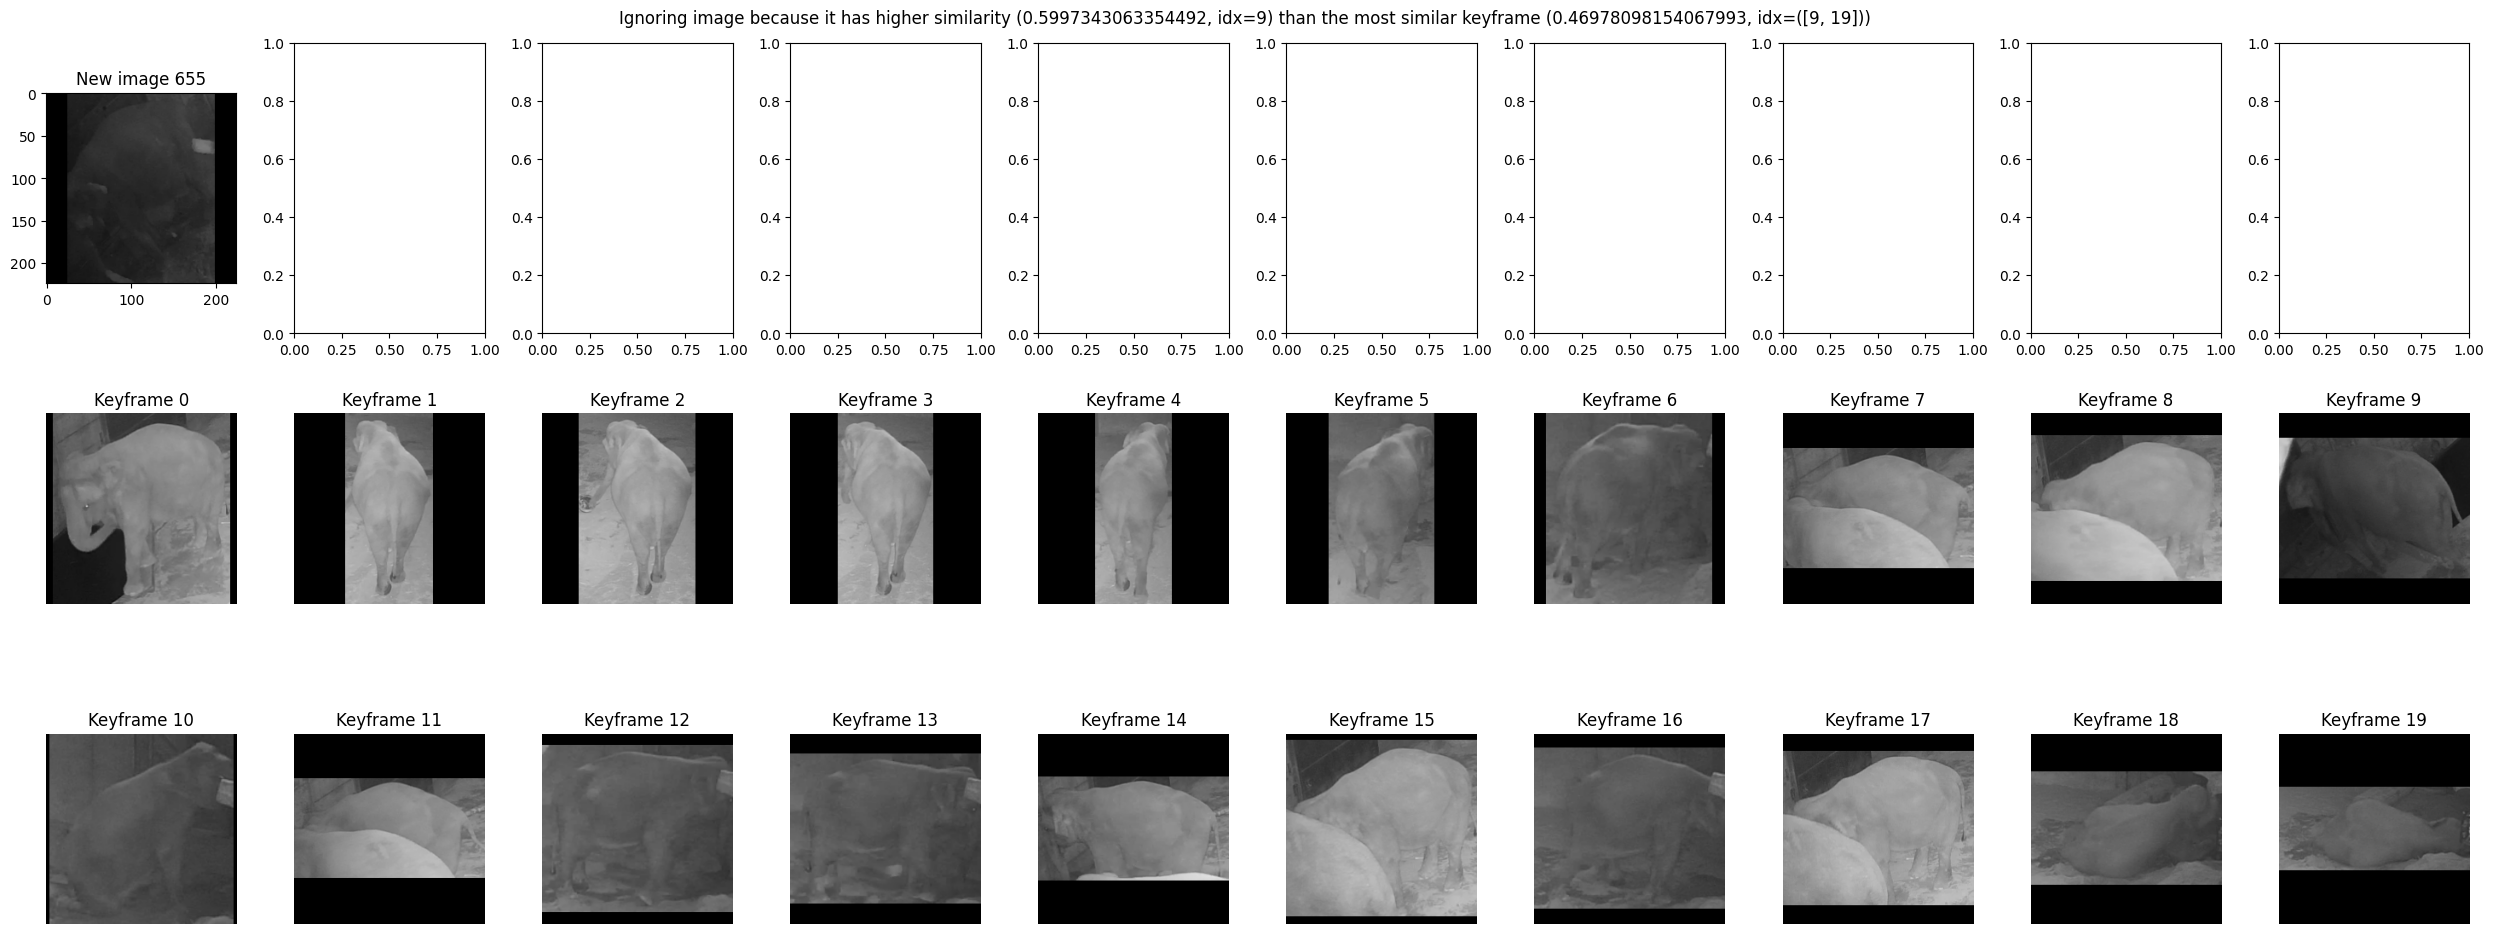

In [ ]:
nrows = 3
ncols = 10
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 10))
ax: Axes = axs[0, 0]
ax.imshow(image)
ax.set_title(f"New image {si}")
axs = axs[1:3, :].reshape(-1)
for i, im in enumerate(keyframe_images):
    ax = axs[i]
    ax.imshow(im)
    ax.set_axis_off()
    ax.set_title(f"Keyframe {i}")
fig.suptitle(msg)
fig.tight_layout()
display.display(plt.gcf())
display.clear_output(wait=True)
time.sleep(0.1)

In [21]:
av, ai = torch.max(a, dim=0)
av, ai

NameError: name 'a' is not defined

In [ ]:
highest_v, highest_i = torch.max(av, dim=0)
two_frames_idx = [highest_i.item(), ai[highest_i].item()]
two_frames_idx

[1, 2]

In [ ]:
a = torch.tensor([[0, 0, 0], [0, 0, 0.1], [0, 0.1, 0]])
a = torch.stack([a, a])
# torch.linalg.norm(a.reshape(2,-1),dim=1).shape
len(a)

2